[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mento-calc/mento/blob/main/docs/source/examples/shear_wall_check_EN_1992-1-1.ipynb)

In [1]:
# Google Colab does not ship mento, so install it when running there.
# Guarded so that building the documentation never shells out to pip.
import sys

if "google.colab" in sys.modules:
    %pip install mento

# Shear Wall check EN 1992-1-1

**Define concrete and steel materials, and then assign the shear wall**

In [2]:
from mento import Concrete_EN_1992_2004, SteelBar, ShearWall, mm, cm, kN, MPa, m
from mento import Forces, Node

# Define materials
concrete = Concrete_EN_1992_2004(name="C25/30", f_c=25 * MPa)
steel = SteelBar(name="B500S", f_y=500 * MPa)

# Define wall geometry. EN 1992-1-1 reads only the length and the thickness for
# in-plane shear: d = 0.8 lw, z = 0.9 d.
wall = ShearWall(
    label="W1", concrete=concrete, steel_bar=steel, thickness=20 * cm, length=4.0 * m, height=3.0 * m, c_c=2.5 * cm
)
wall.data

Shear Wall W1, $l_w$=400.00 cm, $t$=20.00 cm, $h_w$=300.00 cm, $c_c$=2.50 cm, Concrete C25/30, Rebar B500S.

**Set horizontal and vertical distributed reinforcement**

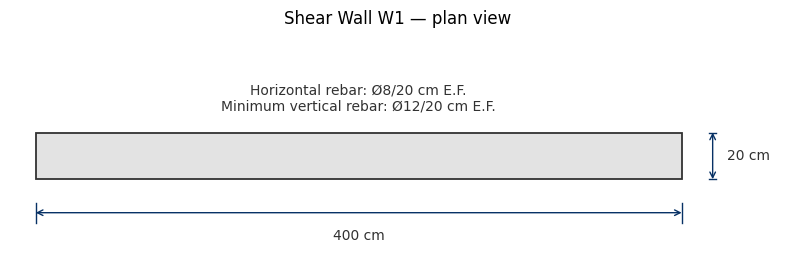

In [3]:
# Horizontal rebar (resists in-plane shear): 2 x Ø8/20, A_sh = 5.03 cm²/m
wall.set_horizontal_rebar(d_b=8 * mm, s=20 * cm)
# Vertical rebar: 2 x Ø12/20, A_sv = 11.31 cm²/m
wall.set_vertical_rebar(d_b=12 * mm, s=20 * cm)
# Plot the wall geometry and reinforcement
wall.plot()

**Define list of forces applied to the wall and create node**

In [4]:
# Define forces acting on the wall. N_x is positive in compression.
f1 = Forces(label="ULS 1", V_z=1200 * kN)
f2 = Forces(label="ULS 2", V_z=800 * kN, N_x=500 * kN)
# Create node with wall and forces
node_1 = Node(section=wall, forces=[f1, f2])
node_1

Node ID: 1 - Section label: W1
Forces Applied:
  - Force ID: 1, Label: ULS 1, N_x: 0.00 kN, V_z: 1200.00 kN, M_y: 0.00 kN·m
  - Force ID: 2, Label: ULS 2, N_x: 500.00 kN, V_z: 800.00 kN, M_y: 0.00 kN·m

**Perform shear check**

In [5]:
# Perform all checks
node_1.check()
# Print results in Markdown format
node_1.results

Shear Wall W1, $l_w$=400.00 cm, $t$=20.00 cm, $h_w$=300.00 cm, $c_c$=2.50 cm, Concrete C25/30, Rebar B500S.

Horizontal rebar: Ø8/20 cm E.F., $\rho_h$=0.00251, Minimum vertical rebar: Ø12/20 cm E.F., $\rho_v$=0.00565, $V_{Ed}$=1200.0 kN, $V_{Rd}$=1573.53 kN → $\color{#439b00}{\text{DCR}=0.76}$ 

In [6]:
# Print shear results in more detailed format in a DataFrame
node_1.check_shear()

,Label,Comb.,"Ash,min","Ash,req",Ash,"Asv,min",Asv,NEd,VEd,"VRd,c","VRd,s",VRd,"VRd,max","VEd≤VRd,max",VEd≤VRd,DCR
0,,,cm²/m,cm²/m,cm²/m,cm²/m,cm²/m,kN,kN,kN,kN,kN,kN,,,
1,W1,ULS 1,2.83,3.83,5.03,4.0,11.31,0.0,1200.0,156.52,1573.53,1573.53,1787.59,True,True,0.763
2,W1,ULS 2,2.83,2.83,5.03,4.0,11.31,500.0,800.0,216.52,1573.53,1573.53,1787.59,True,True,0.508


**Export table results to Excel**

In [7]:
node_1.check_shear().to_excel("EN 1992-1-1 shear_wall_results.xlsx")

**View complete and detailed results for the limiting case of the list of forces**

In [8]:
# View detailed shear results
node_1.shear_results_detailed()

===== SHEAR WALL DETAILED RESULTS =====
Materials                            Variable     Value  Unit
----------------------------------  ----------  -------  ------
Section Label                                        W1
Concrete strength                      fck           25  MPa
Steel reinforcement yield strength     fywk         500  MPa
Safety factor for concrete              γc          1.5
Safety factor for steel                 γs         1.15
Design concrete strength               fcd        16.67  MPa
Design steel strength                  fywd      434.78  MPa 

Geometry              Variable     Value  Unit
-------------------  ----------  -------  ------
Wall thickness           t            20  cm
Wall length              lw          400  cm
Wall height              hw          300  cm
Gross concrete area      Ac         8000  cm²
Effective height         d           320  cm
Lever arm                z           288  cm 

Design forces                     Variable     Valu

**Export detailed results to a Word document**

In [9]:
node_1.shear_results_detailed_doc()